# 2D Optimization Training with TensorBoard

This notebook demonstrates how to run the optimization loop using the `OptimizationTrainer` and visualize progress using TensorBoard directly within the notebook.

In [1]:
%load_ext autoreload
%autoreload 2

In [24]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import torch

from diffmeshopt.opt2d.optimize import ContourRefiner
from diffmeshopt.opt2d.props import OptimizationProps, SamplingProps, TemplateProps
from diffmeshopt.opt2d.trainer import OptimizationTrainer, TrainerConfig


In [5]:
torch.set_float32_matmul_precision("medium")

In [6]:
# 1. Load Data
data_path = Path("/workspace/diffmeshopt/data/2d_training_data.pkl")
if not data_path.exists():
    print(f"Data file {data_path} not found. Please run src/generate_2d_data.py first.")
else:
    print(f"Loading data from {data_path}...")
    data = joblib.load(data_path)
    image_np = -data["image"]  # Invert intensity if needed based on previous notebooks
    contour_np = data["contour"]
    gt_contour_np = data["gt"]

Loading data from /workspace/diffmeshopt/data/2d_training_data.pkl...


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
# 2. Setup Refiner
opt_props = OptimizationProps(
    lr=0.05, w_edge=10, w_laplacian=20, w_sigma_reg=0.0, w_template_shape=0.5
)
sampl_props = SamplingProps(num_samples=51, sample_length=1.0)
template_props = TemplateProps(sigma=0.75, peak_dist=4.5, num_samples=51)

refiner = ContourRefiner(
    image=image_np,
    initial_contour=contour_np,
    optimization_props=opt_props,
    sampling_props=sampl_props,
    template_props=template_props,
    template_mode="global",
)
# refiner.to(device)

In [25]:
# 3. Setup Trainer

train_config = TrainerConfig(
    output_dir="/workspace/diffmeshopt/output/experiment_tb",
    image=image_np,
    gt_contour=contour_np,
    log_interval=10,
    log_image_interval=50,
    save_interval=50,
    use_tensorboard=True,
)

trainer = OptimizationTrainer(
    refiner=refiner,
    config=train_config,
)


/workspace/diffmeshopt/.pixi/envs/default/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /workspace/diffmeshopt/.pixi/envs/default/lib/python ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


In [26]:
# 5. Run Training
trainer.fit(steps_to_run=200)

/workspace/diffmeshopt/.pixi/envs/default/lib/python3.13/site-packages/lightning/pytorch/loops/utilities.py:73: `max_epochs` was not set. Setting it to 1000 epochs. To train without an epoch limit, set `max_epochs=-1`.
/workspace/diffmeshopt/.pixi/envs/default/lib/python3.13/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /workspace/diffmeshopt/output/experiment_tb exists and is not empty.
Restoring states from the checkpoint path at /workspace/diffmeshopt/output/experiment_tb/last.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Restored all states from the checkpoint at /workspace/diffmeshopt/output/experiment_tb/last.ckpt


Output()

/workspace/diffmeshopt/.pixi/envs/default/lib/python3.13/site-packages/lightning/pytorch/loops/training_epoch_loop.
py:224: You're resuming from a checkpoint that ended before the epoch ended and your dataloader is not resumable. 
This can cause unreliable results if further training is done. Consider using an end-of-epoch checkpoint or make 
your dataloader resumable by implementing the `state_dict` / `load_state_dict` interface.

/workspace/diffmeshopt/.pixi/envs/default/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=191` in the `DataLoader` to improve performance.


In [16]:
trainer.fit(resume=True, additional_steps=200)  # To resume from last checkpoint

Restoring states from the checkpoint path at /workspace/diffmeshopt/output/experiment_tb/last.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Restored all states from the checkpoint at /workspace/diffmeshopt/output/experiment_tb/last.ckpt


Output()

/workspace/diffmeshopt/.pixi/envs/default/lib/python3.13/site-packages/lightning/pytorch/loops/training_epoch_loop.
py:224: You're resuming from a checkpoint that ended before the epoch ended and your dataloader is not resumable. 
This can cause unreliable results if further training is done. Consider using an end-of-epoch checkpoint or make 
your dataloader resumable by implementing the `state_dict` / `load_state_dict` interface.

`Trainer.fit` stopped: `max_steps=600` reached.


In [17]:
refiner.template_model.get_params()

{'peak_dist': tensor(3.5460, grad_fn=<ExpBackward0>),
 'sigma': tensor(1.0136, grad_fn=<ExpBackward0>)}

In [18]:
import polars as pl

In [19]:
data = pl.read_parquet("/workspace/diffmeshopt/output/experiment_tb/metrics/0/metrics.parquet")

In [20]:
data

step,total_loss,data_loss,laplacian_loss,edge_loss,shape_loss,sigma_reg,mean_dist,hausdorff_dist,p95_dist,epoch
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64
9,0.813357,0.469981,0.154786,0.083632,0.104958,0.0,0.352895,0.500031,0.500004,0
19,0.673812,0.436321,0.075236,0.071451,0.090804,0.0,0.357822,0.913086,0.727051,0
29,0.609747,0.408698,0.054885,0.065449,0.080715,0.0,0.366137,1.03271,0.720016,0
39,0.609828,0.424141,0.052514,0.062234,0.070939,0.0,0.371951,1.009201,0.746399,0
49,0.60317,0.422436,0.04771,0.060721,0.072303,0.0,0.377795,1.032686,0.772186,0
…,…,…,…,…,…,…,…,…,…,…
159,0.557963,0.406716,0.039333,0.055318,0.056596,0.0,0.424922,1.496662,0.956795,0
169,0.555996,0.399696,0.034965,0.054471,0.066864,0.0,0.430762,1.616261,0.9711,0
179,0.558038,0.400907,0.041062,0.053648,0.062422,0.0,0.434808,1.572292,0.983429,0


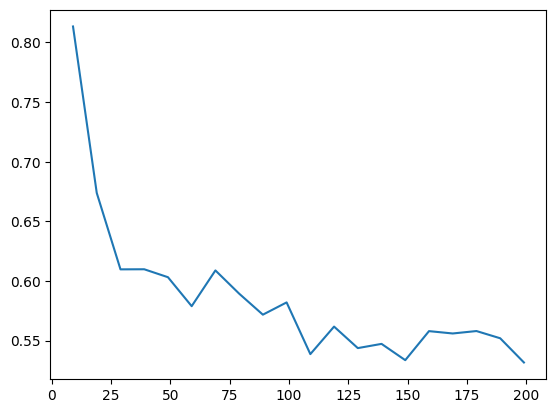

In [21]:
plt.plot(data["step"], data["total_loss"])

(20,)


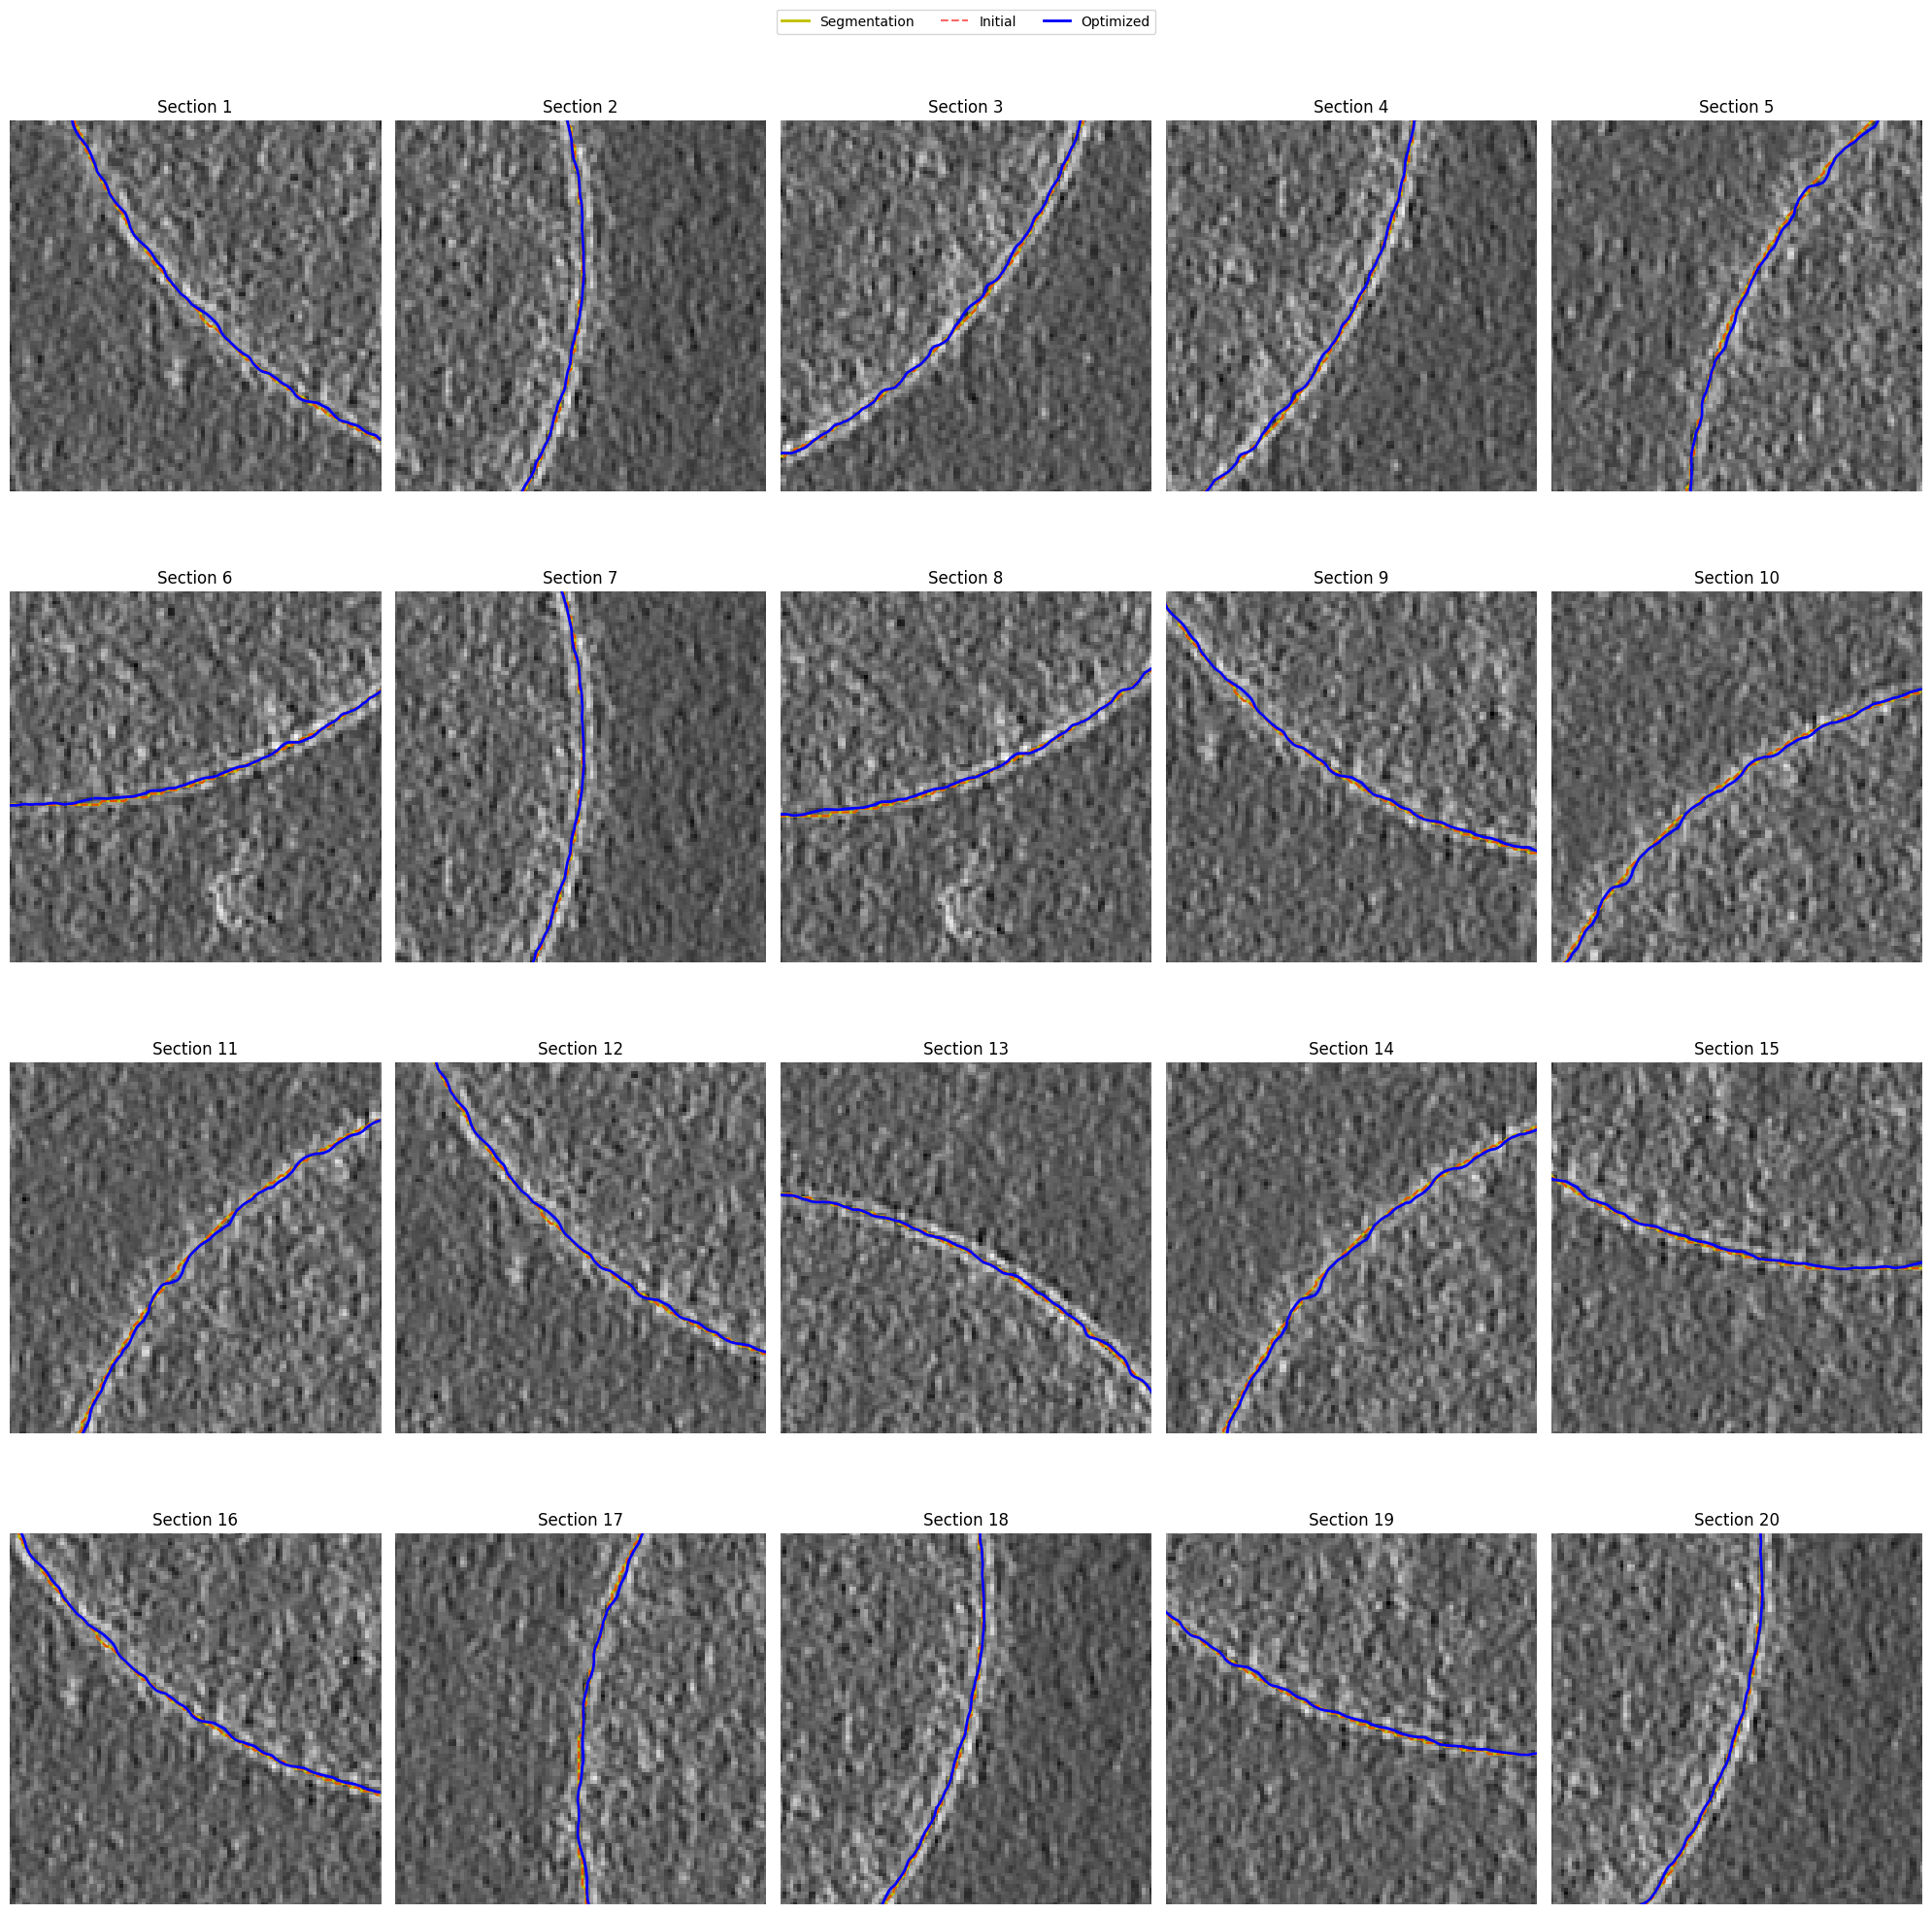

In [22]:
import random

init_contour = contour_np

num_crops = 20
crop_size = 100
half_size = crop_size // 2

# Ensure we have the final contour on CPU
final_contour = refiner.contour.detach().cpu().numpy()

# Select random indices along the final contour to center our crops
# We use the final contour to ensure we look at relevant areas
indices = random.sample(range(len(final_contour)), num_crops)

cols = 5
rows = np.ceil(num_crops / cols).astype(int)
fig, axes = plt.subplots(rows, cols, figsize=(20, 20))
axes = axes.flatten()
# if num_crops == 1:
#    axes = [axes]
print(axes.shape)
H, W = image_np.shape

for i, idx in enumerate(indices):
    ax = axes[i]

    # Center of the crop (row, col) -> (y, x)
    cy, cx = final_contour[idx]

    # Define bounds (handling image edges)
    y_min = max(0, int(cy - half_size))
    y_max = min(H, int(cy + half_size))
    x_min = max(0, int(cx - half_size))
    x_max = min(W, int(cx + half_size))

    # Display the image
    ax.imshow(image_np, cmap="gray")

    # Plot contours
    # Note: plot takes (x, y) which corresponds to (col, row)
    ax.plot(contour_np[:, 1], contour_np[:, 0], "y-", linewidth=2, label="Segmentation")
    ax.plot(
        init_contour[:, 1], init_contour[:, 0], "r--", alpha=0.6, linewidth=1.5, label="Initial"
    )
    ax.plot(final_contour[:, 1], final_contour[:, 0], "b-", linewidth=2, label="Optimized")

    if "gt_contour_np" in locals() and len(gt_contour_np) > 0:
        ax.plot(gt_contour_np[:, 1], gt_contour_np[:, 0], "g:", alpha=0.8, linewidth=2, label="GT")

    # Zoom in by setting axis limits
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_max, y_min)  # Invert Y axis to match image origin (top-left)

    ax.set_title(f"Section {i + 1}")
    ax.axis("off")

# Add a single legend for the figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
plt.show()

In [23]:
template_params = refiner.template_model.get_params()

updated_template_props = template_props.model_copy(
    update={
        "peak_dist": template_params["peak_dist"].detach().cpu().numpy(),
        "sigma": template_params["sigma"].detach().cpu().numpy(),
    }
)
template_props, updated_template_props

(TemplateProps(peak_dist=4.5, sigma=0.75, amp=1.0, num_samples=51, num_control_points=10, neural_hidden_dim=32, neural_num_layers=2),
 TemplateProps(peak_dist=array(3.5460086, dtype=float32), sigma=array(1.0136367, dtype=float32), amp=1.0, num_samples=51, num_control_points=10, neural_hidden_dim=32, neural_num_layers=2))

In [19]:
import diffmeshopt.opt2d.vis as vis2d

In [20]:
import diffmeshopt.opt2d.sampling as sampling2d

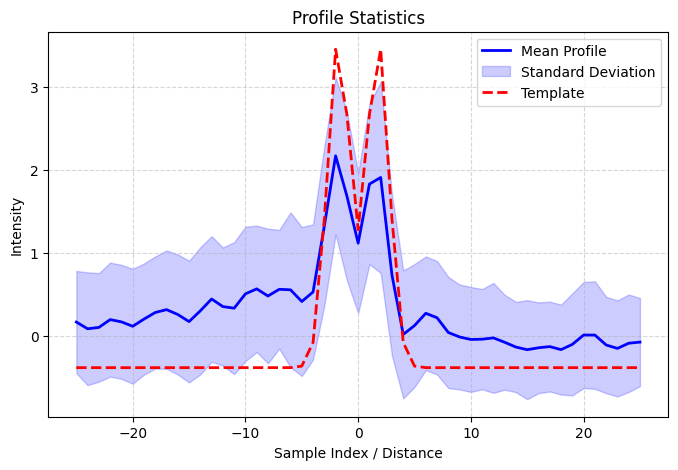

In [21]:
sample_profiles, _, _ = sampling2d.sample_profiles_stochastic(
    torch.from_numpy(image_np).float(),
    torch.from_numpy(contour_np).float(),
    sampling_props=sampl_props,
)

sample_profiles = sample_profiles.detach().cpu().numpy()

fig, ax = plt.subplots(figsize=(8, 5))

vis2d.plot_profile_statistics(sample_profiles, ax=ax, template_props=updated_template_props)
plt.show()

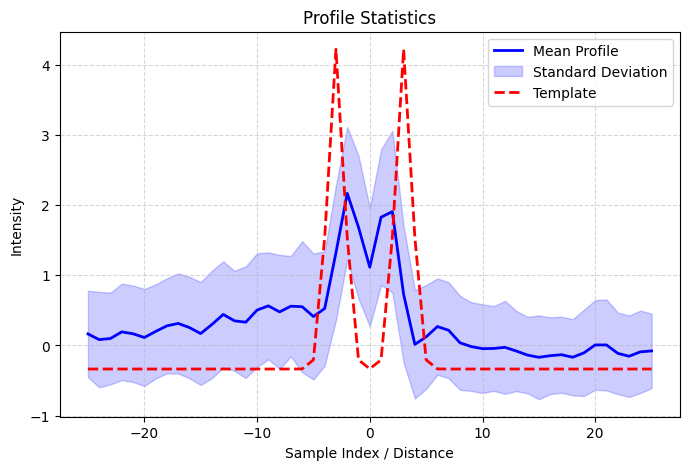

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))

vis2d.plot_profile_statistics(sample_profiles, ax=ax)
plt.show()